# ConvNeXt-StarDist — WSI Inference & Diagnostics

This notebook:
1. **Loads** a trained checkpoint and the matching config.
2. **Explores** the NDPI slide (available levels, MPP, thumbnail).
3. **Diagnoses the encoder** — visualises ConvNeXt stage activations on a single tile.
4. **Diagnoses each head** — prob map, dist map, cls argmax, polygon overlays on a single tile.
5. **Runs whole-slide inference** (batched, timed), **deduplicates** multi-offset/tile-edge hits, then writes **two** GeoJSON files (classified vs segmentation-only).
6. **Visualises results** — centroid overlay, class distribution, per-class example crops.

**Only Cell 3 (Config) needs to be edited between runs.**

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
from __future__ import annotations

import json
import sys
import time
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from tqdm.notebook import tqdm

# Add project root so relative imports work when running the notebook directly
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from shared_convnext_stardist_decoder.model_v2 import build_model_v2
from shared_convnext_stardist_decoder.infer import _normalize_chw, write_geojson
from shared_convnext_stardist_decoder.geometry import (
    local_peaks,
    dist_at_points,
    dist_to_coord,
    polygon_ring_rowcol,
    vote_class,
    dedupe_nucleus_features_by_centroid,
    dedupe_nucleus_features_by_polygon_overlap,
)
from shared_convnext_stardist_decoder.dataset import IMAGENET_MEAN, IMAGENET_STD

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=UserWarning)
print("Imports OK")

Imports OK


In [2]:
# ── Cell 3 · Config  (EDIT THIS CELL FOR EACH RUN) ────────────────────────────

WEIGHTS_PATH = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\convnext_stardist_multitask_runs\run_fold0_FULL\convnext_stardist_mt_gs40_v2_20260408_1956\best.pt")
CONFIG_PATH  = WEIGHTS_PATH.parent / "config_resolved.yaml"     # written by train.py

SLIDE_PATH   = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\monkey_fetus_40_0545.ndpi")

# Run / experiment id for output folder (do not name this `model` — that shadows the NN below).
# Default: folder name of your checkpoint; override if needed.
EXPERIMENT_NAME = WEIGHTS_PATH.parent.name
# EXPERIMENT_NAME = "convnext_stardist_mt_gs40_20260405_2224"

OUT_DIR = SLIDE_PATH.parent / f"inference_{EXPERIMENT_NAME}" / SLIDE_PATH.stem
print(f"OUT_DIR : {OUT_DIR}")

TILE_SIZE    = 256        # must match training patch_size
BATCH_TILES  = 32         # tiles per GPU forward pass — increase for better GPU utilisation
PROB_THRESH  = 0.45       # nucleus detection threshold
NMS_DIST     = 3          # local_peaks min_distance (pixels)
OFFSETS      = [0, TILE_SIZE // 2]   # multi-offset passes; duplicates merged after run (see below)
# Centroid NMS in slide space after all passes — removes multi-offset + tile-edge duplicates.
# Tune ~ expected nuclear diameter (px) at SLIDE_LEVEL; too large merges adjacent real cells.
DEDUP_MIN_DIST_PX = 8.0
# Optional 2nd pass: merge polygons with high overlap (needs shapely). Catches "two masks, one nucleus"
# when centroids stay farther apart than DEDUP_MIN_DIST_PX.
DEDUP_USE_POLYGON_OVERLAP = True
DEDUP_OVERLAP_RATIO = 0.5   # intersection / min(area1, area2); higher = fewer removals
DEDUP_OVERLAP_GRID_PX = 32.0  # spatial hash cell size (px); ~ nuclear diameter is fine

SLIDE_LEVEL  = 0          # OpenSlide level: 0 = full res; increase for fast preview

# ── Speed options ──────────────────────────────────────────────────────────────
# LOAD_TO_RAM: read the entire slide into a numpy array once.
#   Eliminates all per-tile network I/O (recommended for network/remote slides).
#   Memory cost ≈ W × H × 3 bytes at SLIDE_LEVEL.  38k×27k slide → ~3 GB.
LOAD_TO_RAM  = True

# USE_FP16: run the model in half-precision.
#   ~1.5-2× faster on RTX 3090/4090 (Tensor Cores).  No measurable accuracy loss.
USE_FP16     = True

# PREFETCH: background threads to read tiles when LOAD_TO_RAM is False.
#   Overlaps network I/O with GPU compute.  4-8 is usually optimal.
PREFETCH     = 6

# Diagnostic tile (encoder + per-head visualisations) — top-left (x, y) on SLIDE_LEVEL
#   SAMPLE_MODE = "center" → slide centre
#   SAMPLE_MODE = "fixed"  → set SAMPLE_XY = (x, y) explicitly
#   SAMPLE_MODE = "random"→ random location that still fits a full TILE_SIZE patch
SAMPLE_MODE = "random"     # "center" | "fixed" | "random"
SAMPLE_XY   = None         # only used when SAMPLE_MODE == "fixed"
SAMPLE_SEED = None         # e.g. 42 for reproducible random; None = non-deterministic

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# Quick sanity checks
for p, label in [(WEIGHTS_PATH, "weights"), (CONFIG_PATH, "config"), (SLIDE_PATH, "slide")]:
    ok = p.exists()
    print(f"  {label:10s}: {'OK' if ok else 'NOT FOUND'} — {p}")
    if not ok:
        raise FileNotFoundError(f"Missing {label}: {p}")

OUT_DIR : \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\inference_convnext_stardist_mt_gs40_v2_20260408_1956\monkey_fetus_40_0545
Device : cuda
  weights   : OK — \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\convnext_stardist_multitask_runs\run_fold0_FULL\convnext_stardist_mt_gs40_v2_20260408_1956\best.pt
  config    : OK — \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\convnext_stardist_multitask_runs\run_fold0_FULL\convnext_stardist_mt_gs40_v2_20260408_1956\config_resolved.yaml
  slide     : OK — \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\monkey_fetus_40_0545.ndpi


---
## 1 · Model loading & slide explorer

In [3]:
# ── Model loading ─────────────────────────────────────────────────────────────
with CONFIG_PATH.open(encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

model = build_model_v2(cfg).to(DEVICE)
sd = torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(sd, strict=True)
model.eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model   : {type(model).__name__}  ({n_params:.1f} M params)")
print(f"n_rays  : {model.n_rays}   num_classes: {model.num_classes}")

# Load class name mapping saved by train.py
idx2label_path = WEIGHTS_PATH.parent / "idx2label.json"
if idx2label_path.is_file():
    idx2label = {int(k): v for k, v in json.loads(idx2label_path.read_text()).items()}
else:
    cn = cfg.get("model", {}).get("class_names") or []
    idx2label = {i: n for i, n in enumerate(cn)}
    print("  (idx2label.json not found — using class_names from config)")

print(f"Classes : {idx2label}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ConvNextV2Model LOAD REPORT from: facebook/convnextv2-tiny-22k-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model   : StardistMultitaskNetV2  (31.5 M params)
n_rays  : 32   num_classes: 19
Classes : {0: 'bladder', 1: 'bone', 2: 'brain', 3: 'collagen', 4: 'ear', 5: 'eye', 6: 'gi', 7: 'heart', 8: 'kidney', 9: 'liver', 10: 'lungs', 11: 'mesokidney', 12: 'nontissue', 13: 'pancreas', 14: 'skull', 15: 'spleen', 16: 'spleen2', 17: 'thymus', 18: 'thyroid'}


Slide   : monkey_fetus_40_0545.ndpi
Format  : hamamatsu
Levels  : 8
  Level 0: 38400×26752  downsample=1.0x  0.442 µm/px
  Level 1: 19200×13376  downsample=2.0x  0.883 µm/px
  Level 2: 9600×6688  downsample=4.0x  1.766 µm/px
  Level 3: 4800×3344  downsample=8.0x  3.533 µm/px
  Level 4: 2400×1672  downsample=16.0x  7.065 µm/px
  Level 5: 1200×836  downsample=32.0x  14.131 µm/px
  Level 6: 600×418  downsample=64.0x  28.261 µm/px
  Level 7: 300×209  downsample=128.0x  56.522 µm/px


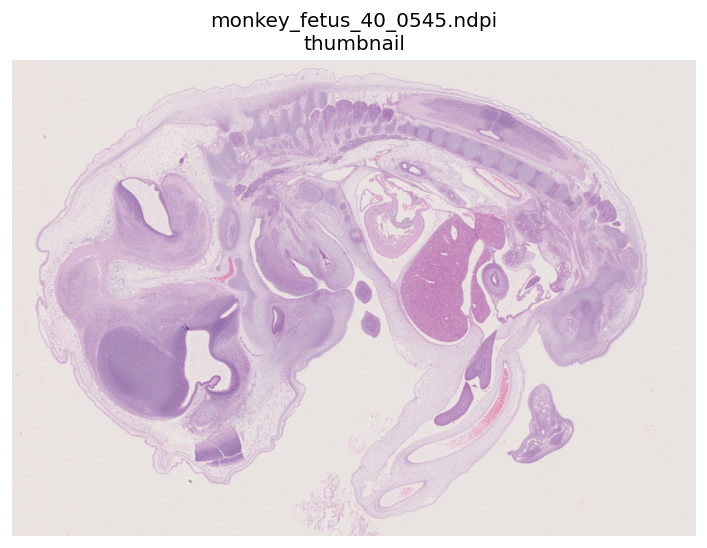

In [4]:
# ── Slide explorer ────────────────────────────────────────────────────────────
import openslide

slide = openslide.OpenSlide(str(SLIDE_PATH))

print(f"Slide   : {SLIDE_PATH.name}")
print(f"Format  : {slide.properties.get(openslide.PROPERTY_NAME_VENDOR, 'unknown')}")
print(f"Levels  : {slide.level_count}")
for lvl in range(slide.level_count):
    w, h = slide.level_dimensions[lvl]
    ds   = slide.level_downsamples[lvl]
    mpp  = slide.properties.get(f"openslide.mpp-x", "?")
    try:
        mpp_lvl = float(mpp) * ds if mpp != "?" else "?"
        mpp_str = f"{mpp_lvl:.3f} µm/px" if isinstance(mpp_lvl, float) else "?"
    except Exception:
        mpp_str = "?"
    print(f"  Level {lvl}: {w}×{h}  downsample={ds:.1f}x  {mpp_str}")

# Thumbnail
thumb = slide.get_thumbnail((1024, 1024))
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(thumb)
ax.set_title(f"{SLIDE_PATH.name}\nthumbnail")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 2 · Single-tile extraction (used for diagnostics)

Random diagnostic tile top-left (10386, 7471) on level 0  seed=None


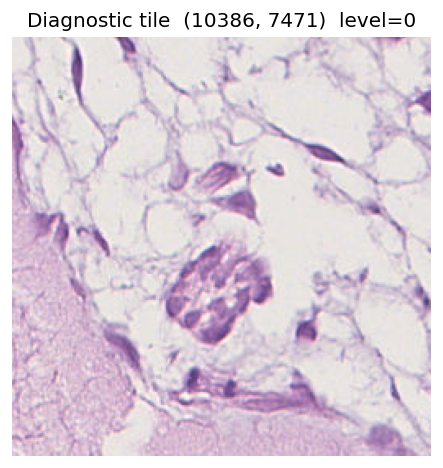

Tile shape: (256, 256, 3)


In [5]:
# ── Extract a representative tile ─────────────────────────────────────────────
W, H = slide.level_dimensions[SLIDE_LEVEL]
ds   = slide.level_downsamples[SLIDE_LEVEL]

sm = str(SAMPLE_MODE).strip().lower()
if sm == "fixed":
    if SAMPLE_XY is None:
        raise ValueError("SAMPLE_MODE is 'fixed' but SAMPLE_XY is None — set SAMPLE_XY = (x, y) on SLIDE_LEVEL")
    sx, sy = int(SAMPLE_XY[0]), int(SAMPLE_XY[1])
elif sm == "random":
    rng = np.random.default_rng(SAMPLE_SEED)
    tw = min(TILE_SIZE, W)
    th = min(TILE_SIZE, H)
    x_max = max(0, W - tw)
    y_max = max(0, H - th)
    sx = int(rng.integers(0, x_max + 1)) if x_max > 0 else 0
    sy = int(rng.integers(0, y_max + 1)) if y_max > 0 else 0
    print(f"Random diagnostic tile top-left ({sx}, {sy}) on level {SLIDE_LEVEL}  seed={SAMPLE_SEED!r}")
else:
    # centre (default)
    if sm not in ("center", "centre"):
        print(f"Unknown SAMPLE_MODE={SAMPLE_MODE!r} — using center")
    sx = max(0, W // 2 - TILE_SIZE // 2)
    sy = max(0, H // 2 - TILE_SIZE // 2)

# Read at most TILE_SIZE×TILE_SIZE (clip at slide edges)
rw = min(TILE_SIZE, W - sx)
rh = min(TILE_SIZE, H - sy)
# OpenSlide read_region expects level-0 coordinates
region = slide.read_region(
    (int(sx * ds), int(sy * ds)), SLIDE_LEVEL, (rw, rh)
)
sample_rgb = np.asarray(region.convert("RGB"), dtype=np.uint8)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample_rgb)
ax.set_title(f"Diagnostic tile  ({sx}, {sy})  level={SLIDE_LEVEL}")
ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Tile shape: {sample_rgb.shape}")

---
## 3 · Encoder feature map diagnostics

Encoder stage shapes: [(96, 64, 64), (192, 32, 32), (384, 16, 16), (768, 8, 8)]


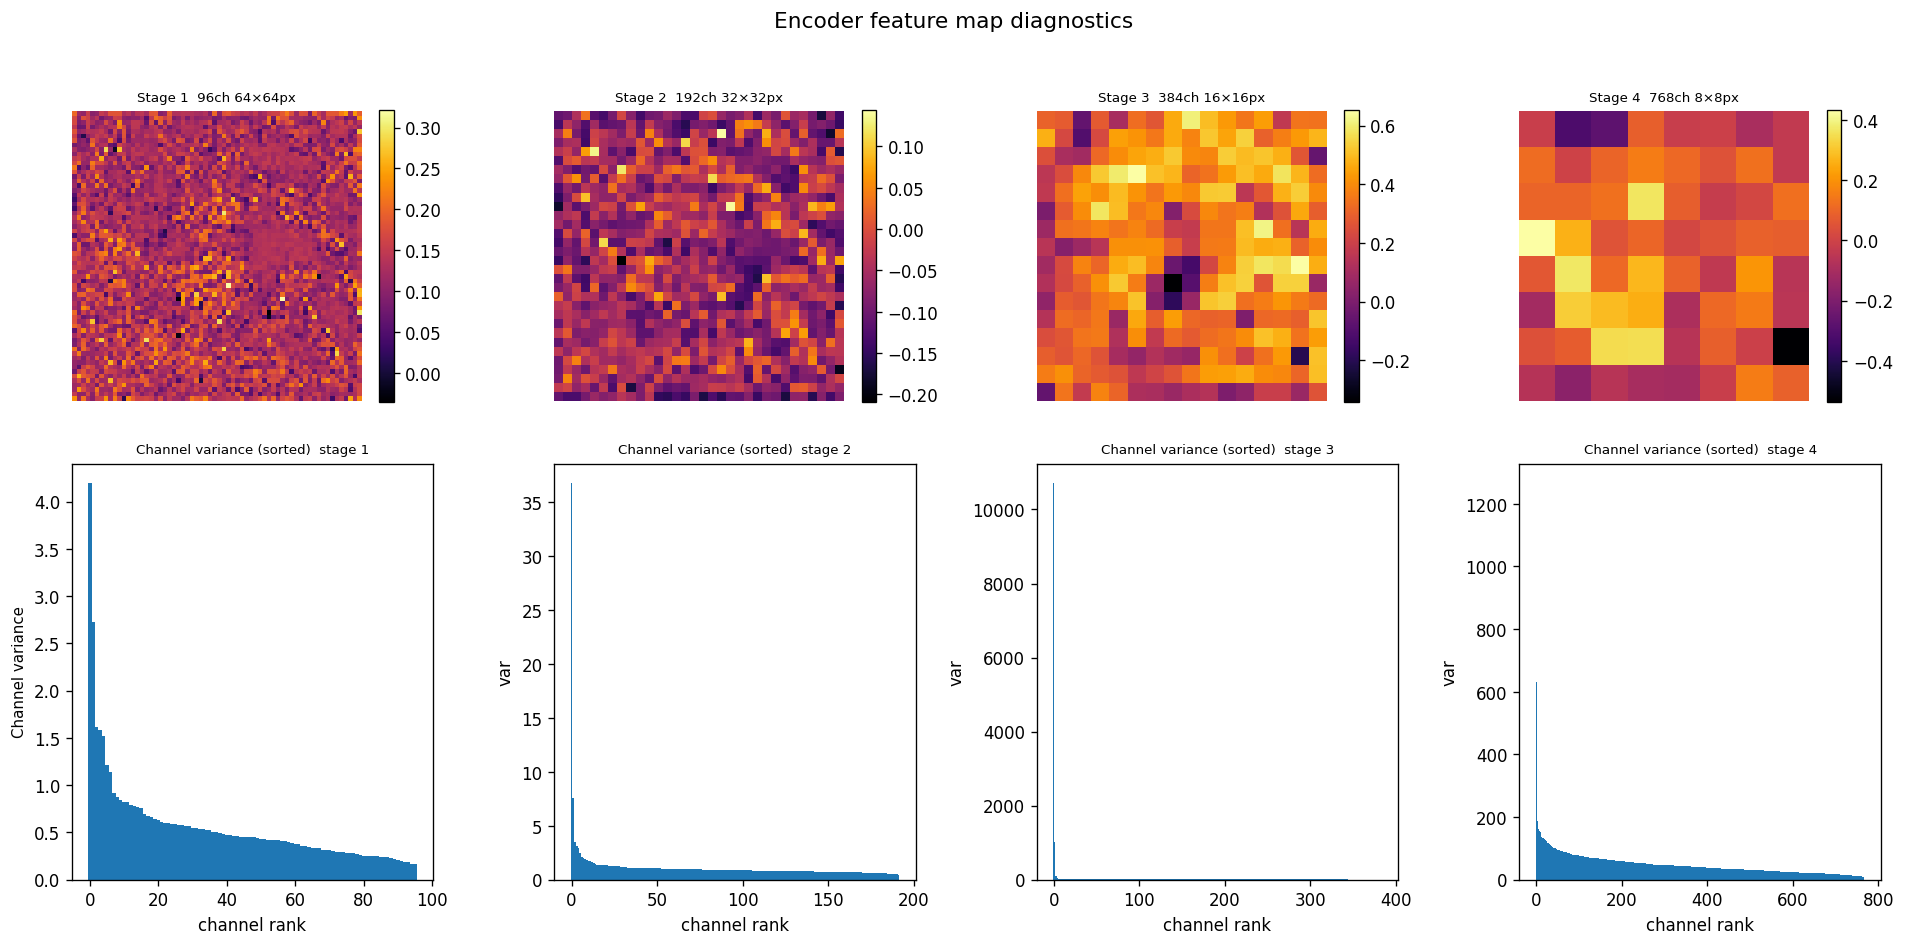

  Stage 1: 0/96 dead channels    mean activation=0.1334  max=22.9871
  Stage 2: 0/192 dead channels    mean activation=-0.0559  max=28.1222
  Stage 3: 0/384 dead channels    mean activation=0.3204  max=543.9053
  Stage 4: 0/768 dead channels    mean activation=0.0599  max=126.8527


In [6]:
# ── Encoder feature diagnostics ───────────────────────────────────────────────
# Extract the 4 ConvNeXt stage feature maps (hidden_states[1:] from HF backbone)
# Stage shapes for a 256×256 input:
#   stage 0 → (96,  64, 64)  1/4
#   stage 1 → (192, 32, 32)  1/8
#   stage 2 → (384, 16, 16)  1/16
#   stage 3 → (768, 8,  8 )  1/32

@torch.no_grad()
def get_encoder_features(model, rgb_hwc: np.ndarray):
    """Returns list of 4 numpy arrays (C, H, W), one per encoder stage."""
    x = _normalize_chw(rgb_hwc).unsqueeze(0).to(DEVICE)
    out = model.backbone(x, output_hidden_states=True)
    return [f[0].float().cpu().numpy() for f in out.hidden_states[1:]]


feats = get_encoder_features(model, sample_rgb)
stage_labels = [f"Stage {i+1}  {f.shape[0]}ch {f.shape[1]}×{f.shape[2]}px"
                for i, f in enumerate(feats)]
print("Encoder stage shapes:", [f.shape for f in feats])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Encoder feature map diagnostics", fontsize=13)

for col, (f, lbl) in enumerate(zip(feats, stage_labels)):
    # Row 0: mean activation across channels → spatial heat map
    mean_act = f.mean(axis=0)
    im0 = axes[0, col].imshow(mean_act, cmap="inferno", interpolation="nearest")
    axes[0, col].set_title(lbl, fontsize=8)
    axes[0, col].axis("off")
    plt.colorbar(im0, ax=axes[0, col], shrink=0.7)

    # Row 1: channel variance across H×W → which channels are active?
    ch_var = f.var(axis=(1, 2))                       # (C,)
    axes[1, col].bar(range(len(ch_var)), np.sort(ch_var)[::-1], width=1.0)
    axes[1, col].set_title(f"Channel variance (sorted)  stage {col+1}", fontsize=8)
    axes[1, col].set_xlabel("channel rank")
    axes[1, col].set_ylabel("var")

axes[0, 0].set_ylabel("Mean activation", fontsize=9)
axes[1, 0].set_ylabel("Channel variance", fontsize=9)
plt.tight_layout()
plt.show()

# Summary: fraction of dead channels (var < 1e-5) per stage
for i, f in enumerate(feats):
    dead = (f.var(axis=(1, 2)) < 1e-5).sum()
    print(f"  Stage {i+1}: {dead}/{f.shape[0]} dead channels  "
          f"  mean activation={f.mean():.4f}  max={f.max():.4f}")

---
## 4 · Per-head output visualization

Detected 42 nuclei in diagnostic tile


C:\Users\Andre\AppData\Local\Temp\ipykernel_55208\1339066827.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap20 = plt.cm.get_cmap("tab20", model.num_classes)


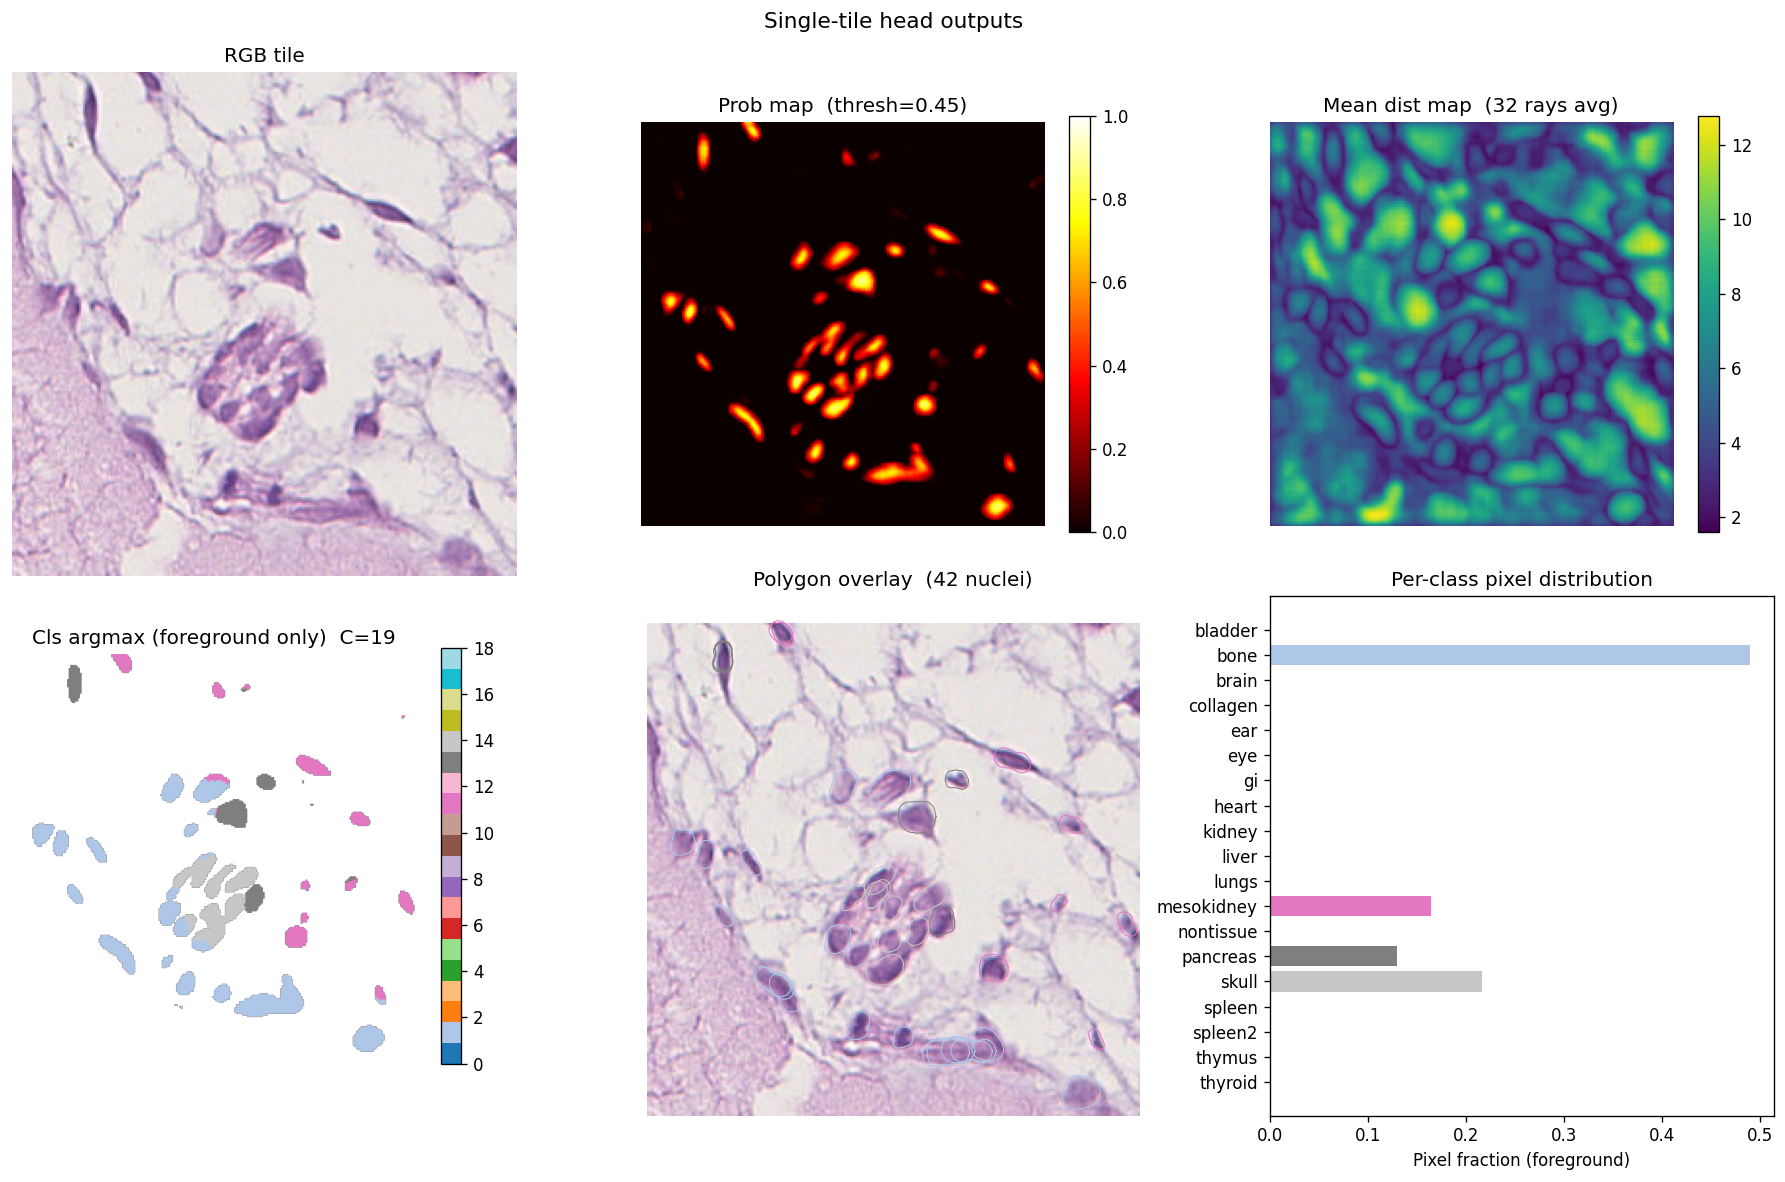

In [7]:
# ── Per-head output visualization ─────────────────────────────────────────────

@torch.no_grad()
def run_tile(model, rgb_hwc: np.ndarray):
    """Run one tile through the full model; return prob, dist, cls_logit."""
    ph, pw = rgb_hwc.shape[:2]
    # Pad to multiple of 32
    nh = int(np.ceil(ph / 32) * 32)
    nw = int(np.ceil(pw / 32) * 32)
    if nh != ph or nw != pw:
        pad = np.zeros((nh, nw, 3), dtype=np.uint8)
        pad[:ph, :pw] = rgb_hwc
        rgb_hwc = pad
    x = _normalize_chw(rgb_hwc).unsqueeze(0).to(DEVICE)
    prob_logit, dist_t, cls_logit = model(x)
    prob     = torch.sigmoid(prob_logit)[0, 0].float().cpu().numpy()[:ph, :pw]
    dist_map = dist_t[0].float().cpu().numpy()[:, :ph, :pw]        # (n_rays, H, W)
    cls_log  = cls_logit[0].float().cpu().numpy()[:, :ph, :pw]     # (C, H, W)
    return prob, dist_map, cls_log


prob, dist_map, cls_log = run_tile(model, sample_rgb)

# Derived maps
mean_dist   = dist_map.mean(axis=0)                                # mean across rays
cls_argmax  = cls_log.argmax(axis=0)                               # (H, W)

# Detected nuclei
peaks = local_peaks(prob, min_distance=int(NMS_DIST), thresh=float(PROB_THRESH))
print(f"Detected {len(peaks)} nuclei in diagnostic tile")

n_cls_detected = len({vote_class(cls_log, dist_to_coord(
    dist_at_points(np.transpose(dist_map, (1, 2, 0)), peaks[k:k+1]),
    peaks[k:k+1].astype(np.float32)
)[0], sample_rgb.shape[:2])[0] for k in range(min(len(peaks), 50))})

# 2×3 panel
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Single-tile head outputs", fontsize=13)

# [0,0] RGB
axes[0, 0].imshow(sample_rgb)
axes[0, 0].set_title("RGB tile")
axes[0, 0].axis("off")

# [0,1] Prob map
im1 = axes[0, 1].imshow(prob, cmap="hot", vmin=0, vmax=1)
axes[0, 1].set_title(f"Prob map  (thresh={PROB_THRESH})")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

# [0,2] Mean dist map
im2 = axes[0, 2].imshow(mean_dist, cmap="viridis")
axes[0, 2].set_title(f"Mean dist map  ({model.n_rays} rays avg)")
axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], shrink=0.8)

# [1,0] Cls argmax (only over foreground mask = prob > 0.1)
fg_mask = prob > 0.1
cls_display = np.where(fg_mask, cls_argmax, -1).astype(float)
cls_display[cls_display < 0] = np.nan
im3 = axes[1, 0].imshow(cls_display, cmap="tab20",
                         vmin=0, vmax=max(model.num_classes - 1, 1))
axes[1, 0].set_title(f"Cls argmax (foreground only)  C={model.num_classes}")
axes[1, 0].axis("off")
plt.colorbar(im3, ax=axes[1, 0], shrink=0.8)

# [1,1] Polygon overlay
axes[1, 1].imshow(sample_rgb)
if len(peaks) > 0:
    dists_pk  = dist_at_points(np.transpose(dist_map, (1, 2, 0)), peaks)
    coords_pk = dist_to_coord(dists_pk, peaks.astype(np.float32))  # (N, 2, n_rays)
    cmap20 = plt.cm.get_cmap("tab20", model.num_classes)
    for k in range(coords_pk.shape[0]):
        cls_id, _ = vote_class(cls_log, coords_pk[k], sample_rgb.shape[:2])
        ring = polygon_ring_rowcol(coords_pk[k])   # (n_rays+1, 2) [x, y]
        col  = cmap20(cls_id % model.num_classes) if cls_id >= 0 else "white"
        axes[1, 1].plot(ring[:, 0], ring[:, 1], linewidth=0.6, color=col)
axes[1, 1].set_title(f"Polygon overlay  ({len(peaks)} nuclei)")
axes[1, 1].axis("off")

# [1,2] Per-class pixel fraction bar chart (foreground only)
fg_classes = cls_argmax[fg_mask]
counts = np.bincount(fg_classes, minlength=model.num_classes)
fracs  = counts / (counts.sum() + 1e-9)
xlabels = [idx2label.get(i, str(i)) for i in range(model.num_classes)]
axes[1, 2].barh(xlabels, fracs, color=plt.cm.tab20(np.linspace(0, 1, model.num_classes)))
axes[1, 2].set_xlabel("Pixel fraction (foreground)")
axes[1, 2].set_title("Per-class pixel distribution")
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 5 · Whole-slide inference (batched, timed)

In [8]:
# ── Batched WSI inference ─────────────────────────────────────────────────────
# Reads the full slide at SLIDE_LEVEL, splits into TILE_SIZE tiles with OFFSETS
# passes, batches BATCH_TILES tiles per GPU forward call, and collects GeoJSON features.

def _read_slide_region(slide, x0, y0, level, tile_w, tile_h):
    """Read region; returns (H,W,3) uint8 array."""
    ds = slide.level_downsamples[level]
    region = slide.read_region((int(x0 * ds), int(y0 * ds)), level, (tile_w, tile_h))
    return np.asarray(region.convert("RGB"), dtype=np.uint8)


@torch.no_grad()
def _batch_forward(model, patches_hwc: list[np.ndarray], device):
    """Run a batch of (possibly different-sized) patches; returns lists of (prob, dist, cls_log)."""
    # Pad each patch to the same tile size (multiple of 32) and stack
    sizes = [(p.shape[0], p.shape[1]) for p in patches_hwc]
    max_h = int(np.ceil(max(s[0] for s in sizes) / 32) * 32)
    max_w = int(np.ceil(max(s[1] for s in sizes) / 32) * 32)
    tensors = []
    for p in patches_hwc:
        ph, pw = p.shape[:2]
        if ph != max_h or pw != max_w:
            pad = np.zeros((max_h, max_w, 3), dtype=np.uint8)
            pad[:ph, :pw] = p
            p = pad
        tensors.append(_normalize_chw(p))
    batch = torch.stack(tensors).to(device)   # (B, 3, H, W)
    prob_logit, dist_b, cls_b = model(batch)
    results = []
    for i, (ph, pw) in enumerate(sizes):
        prob    = torch.sigmoid(prob_logit[i, 0]).float().cpu().numpy()[:ph, :pw]
        dist_m  = dist_b[i].float().cpu().numpy()[:, :ph, :pw]
        cls_log = cls_b[i].float().cpu().numpy()[:, :ph, :pw]
        results.append((prob, dist_m, cls_log))
    return results


# ════════════════════════════════════════════════════════════════════════════════
# OPTIMISED INFERENCE
# Why was GPU at 32%?
#   slide is on network share → read_region = network round-trip + JPEG decomp
#   BATCH_TILES=8 → GPU done in ~5 ms, waits ~50 ms for I/O
#   Tensor Cores need ≥32 tiles to be efficient
#
# Fixes:
#   1. LOAD_TO_RAM   — read entire slide once; zero per-tile network cost
#   2. USE_FP16      — fp16 forward; ~1.5-2× faster on RTX 4090 Tensor Cores
#   3. BATCH_TILES=32 — better GPU occupancy
#   4. cudnn.benchmark — cuDNN picks fastest conv algo for fixed shapes
#   5. Async prefetch — ThreadPoolExecutor overlaps I/O with GPU compute
# ════════════════════════════════════════════════════════════════════════════════

import concurrent.futures

torch.backends.cudnn.benchmark = True

# ── 1. Load full slide to RAM (eliminates per-tile network I/O) ───────────────
W_slide, H_slide = slide.level_dimensions[SLIDE_LEVEL]
_slide_ram = None

if LOAD_TO_RAM:
    ram_mb = W_slide * H_slide * 3 / 1e6
    print(f"Loading slide to RAM  ({W_slide}×{H_slide} px  ~{ram_mb:.0f} MB) ...")
    _t = time.perf_counter()
    _slide_ram = np.asarray(
        slide.read_region((0, 0), SLIDE_LEVEL, (W_slide, H_slide)).convert("RGB"),
        dtype=np.uint8,
    )
    print(f"  Done in {time.perf_counter()-_t:.1f}s — all tiles now served from RAM")
else:
    print("LOAD_TO_RAM=False — async prefetch active (set LOAD_TO_RAM=True for max speed on network slides)")


def _get_tile(x0, y0, tw, th):
    """Slice from RAM array or fetch from OpenSlide."""
    if _slide_ram is not None:
        return _slide_ram[y0:y0+th, x0:x0+tw].copy()
    ds = slide.level_downsamples[SLIDE_LEVEL]
    return np.asarray(
        slide.read_region((int(x0 * ds), int(y0 * ds)), SLIDE_LEVEL, (tw, th)).convert("RGB"),
        dtype=np.uint8,
    )


# ── 2. fp16 model ─────────────────────────────────────────────────────────────
_infer_dtype = torch.float16 if (USE_FP16 and DEVICE.type == "cuda") else torch.float32
if _infer_dtype == torch.float16:
    model.half()
    print("fp16 inference  enabled")
else:
    model.float()
    print("fp32 inference (fp16 disabled or CPU)")


@torch.no_grad()
def _batch_forward_fast(patches_hwc: list):
    sizes = [(p.shape[0], p.shape[1]) for p in patches_hwc]
    max_h = int(np.ceil(max(s[0] for s in sizes) / 32) * 32)
    max_w = int(np.ceil(max(s[1] for s in sizes) / 32) * 32)
    tensors = []
    for p in patches_hwc:
        ph, pw = p.shape[:2]
        if ph != max_h or pw != max_w:
            pad = np.zeros((max_h, max_w, 3), dtype=np.uint8)
            pad[:ph, :pw] = p
            p = pad
        t = _normalize_chw(p)
        if _infer_dtype == torch.float16:
            t = t.half()
        tensors.append(t)
    batch = torch.stack(tensors).to(DEVICE, non_blocking=True)
    with torch.amp.autocast("cuda", enabled=(_infer_dtype == torch.float16)):
        prob_logit, dist_b, cls_b = model(batch)
    results = []
    for i, (ph, pw) in enumerate(sizes):
        prob    = torch.sigmoid(prob_logit[i, 0]).float().cpu().numpy()[:ph, :pw]
        dist_m  = dist_b[i].float().cpu().numpy()[:, :ph, :pw]
        cls_log = cls_b[i].float().cpu().numpy()[:, :ph, :pw]
        results.append((prob, dist_m, cls_log))
    return results


# ── 3. Build tile list ────────────────────────────────────────────────────────
tile_coords = []
for oy in OFFSETS:
    for ox in OFFSETS:
        for y0 in range(oy, H_slide, TILE_SIZE):
            for x0 in range(ox, W_slide, TILE_SIZE):
                y1 = min(y0 + TILE_SIZE, H_slide)
                x1 = min(x0 + TILE_SIZE, W_slide)
                if (y1 - y0) < 8 or (x1 - x0) < 8:
                    continue
                tile_coords.append((x0, y0, x1 - x0, y1 - y0))

print(f"\nStarting WSI inference on level {SLIDE_LEVEL} ...")
print(f"  Slide size  : {W_slide}×{H_slide} px")
print(f"  Total tiles : {len(tile_coords)}  (offsets={OFFSETS})")
print(f"  Batch size  : {BATCH_TILES}  |  fp16={USE_FP16}  |  RAM={LOAD_TO_RAM}")

# ── 4. Run with async prefetch ────────────────────────────────────────────────
ALL_FEATURES = []
feat_id = 0
n_workers = 1 if (_slide_ram is not None) else PREFETCH

t0 = time.perf_counter()
t_io = t_gpu = 0.0

with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
    pbar = tqdm(total=len(tile_coords), desc="Inferring tiles", unit="tile")

    for batch_start in range(0, len(tile_coords), BATCH_TILES):
        batch_meta = tile_coords[batch_start: batch_start + BATCH_TILES]

        _t = time.perf_counter()
        futures = [pool.submit(_get_tile, x0, y0, tw, th) for x0, y0, tw, th in batch_meta]
        patches = [f.result() for f in futures]
        t_io += time.perf_counter() - _t

        _t = time.perf_counter()
        results = _batch_forward_fast(patches)
        t_gpu += time.perf_counter() - _t

        for (x0, y0, tw, th), (prob, dist_map, cls_log) in zip(batch_meta, results):
            peaks = local_peaks(prob, min_distance=int(NMS_DIST), thresh=float(PROB_THRESH))
            if len(peaks) == 0:
                continue
            dists  = dist_at_points(np.transpose(dist_map, (1, 2, 0)), peaks)
            coords = dist_to_coord(dists, peaks.astype(np.float32))
            for k in range(coords.shape[0]):
                rc        = coords[k]
                cls_id, probs_k = vote_class(cls_log, rc, (th, tw))
                ring      = polygon_ring_rowcol(rc)
                ring_glob = ring + np.array([x0, y0], dtype=np.float32)
                name = idx2label.get(cls_id, f"class_{cls_id}")
                ALL_FEATURES.append({
                    "type": "Feature",
                    "id": str(feat_id),
                    "geometry": {"type": "Polygon", "coordinates": [ring_glob.tolist()]},
                    "properties": {
                        "classification": {"name": name, "index": int(cls_id)},
                        "prob_peak": float(prob[int(peaks[k, 0]), int(peaks[k, 1])]),
                        "class_probs": {
                            idx2label.get(i, str(i)): float(p)
                            for i, p in enumerate(probs_k)
                        },
                    },
                })
                feat_id += 1
        pbar.update(len(batch_meta))
        pbar.set_postfix(nuclei=feat_id)

    pbar.close()

_n_raw = len(ALL_FEATURES)
_t_d0 = time.perf_counter()
ALL_FEATURES = dedupe_nucleus_features_by_centroid(
    ALL_FEATURES, min_dist_px=float(DEDUP_MIN_DIST_PX)
)
for i, feat in enumerate(ALL_FEATURES):
    feat["id"] = str(i)
t_dedupe = time.perf_counter() - _t_d0

_n_after_centroid = len(ALL_FEATURES)
t_overlap = 0.0
if DEDUP_USE_POLYGON_OVERLAP:
    _t_o0 = time.perf_counter()
    ALL_FEATURES = dedupe_nucleus_features_by_polygon_overlap(
        ALL_FEATURES,
        min_overlap_ratio=float(DEDUP_OVERLAP_RATIO),
        grid_cell_px=float(DEDUP_OVERLAP_GRID_PX),
    )
    for i, feat in enumerate(ALL_FEATURES):
        feat["id"] = str(i)
    t_overlap = time.perf_counter() - _t_o0

ELAPSED = time.perf_counter() - t0

# Restore fp32 so diagnostic cells can be re-run after this cell
if _infer_dtype == torch.float16:
    model.float()

print(
    f"\nDedup centroid : {_n_raw:,} -> {_n_after_centroid:,}  "
    f"(min_dist={DEDUP_MIN_DIST_PX} px, {t_dedupe:.1f}s)"
)
if DEDUP_USE_POLYGON_OVERLAP:
    print(
        f"Dedup overlap  : {_n_after_centroid:,} -> {len(ALL_FEATURES):,}  "
        f"(min_overlap_ratio={DEDUP_OVERLAP_RATIO}, {t_overlap:.1f}s)"
    )
print(f"Done : {len(ALL_FEATURES):,} nuclei (after dedup)")
print(f"Time : {ELAPSED:.1f} s   ({ELAPSED/60:.1f} min)")
if ELAPSED > 0:
    print(f"Speed: {len(ALL_FEATURES)/ELAPSED:.0f} nuclei/s  |  "
          f"{len(tile_coords)/ELAPSED:.1f} tiles/s")
    print(f"\nTime breakdown:")
    print(f"  I/O  (tile read/slice) : {t_io:.1f}s  ({100*t_io/ELAPSED:.0f}%)")
    print(f"  GPU  (forward pass)    : {t_gpu:.1f}s  ({100*t_gpu/ELAPSED:.0f}%)")
    print(f"  Dedup centroid NMS     : {t_dedupe:.1f}s  ({100*t_dedupe/ELAPSED:.0f}%)")
    print(f"  Dedup polygon overlap  : {t_overlap:.1f}s  ({100*t_overlap/ELAPSED:.0f}%)")
    rest = ELAPSED - t_io - t_gpu - t_dedupe - t_overlap
    print(f"  CPU  (other post)      : {rest:.1f}s  ({100*max(rest,0)/ELAPSED:.0f}%)")

Loading slide to RAM  (38400×26752 px  ~3082 MB) ...
  Done in 43.9s — all tiles now served from RAM
fp16 inference  enabled

Starting WSI inference on level 0 ...
  Slide size  : 38400×26752 px
  Total tiles : 62700  (offsets=[0, 128])
  Batch size  : 32  |  fp16=True  |  RAM=True


Inferring tiles:   0%|          | 0/62700 [00:00<?, ?tile/s]

ImportError: dedupe_nucleus_features_by_polygon_overlap needs shapely>=2. Install shapely or disable polygon overlap deduplication.

---
## 6 · GeoJSON writing & summary

In [ ]:
# ── GeoJSON writing (2 files) ─────────────────────────────────────────────────
#  1) classified: tissue class + display colour (tab20, same as plots below)
#  2) segmentation: polygon only (no classification)
import matplotlib.colors as mcolors

OUT_DIR.mkdir(parents=True, exist_ok=True)

nc = max(int(model.num_classes), 1)
cmap_cls = plt.cm.get_cmap("tab20", nc)
CLASS_COLOR_HEX = {i: mcolors.rgb2hex(cmap_cls(i % nc)[:3]) for i in range(nc)}
# QuPath 0.6 (GsonTools PathClass): use RGB array [r,g,b] under classification.color,
# or legacy colorRGB — not Web hex strings.
CLASS_COLOR_RGB = {
    i: [int(CLASS_COLOR_HEX[i][1:3], 16), int(CLASS_COLOR_HEX[i][3:5], 16), int(CLASS_COLOR_HEX[i][5:7], 16)]
    for i in range(nc)
}


def _feat_classified(feat: dict) -> dict:
    cls_idx = int(feat["properties"]["classification"]["index"])
    name = feat["properties"]["classification"]["name"]
    rgb = CLASS_COLOR_RGB.get(cls_idx, [128, 128, 128])
    return {
        "type": "Feature",
        "id": feat["id"],
        "geometry": feat["geometry"],
        "properties": {
            "isLocked": False,
            "measurements": [],
            "classification": {
                "name": name,
                "color": rgb,
            },
            "prob_peak": feat["properties"].get("prob_peak"),
        },
    }


def _feat_segmentation_only(feat: dict) -> dict:
    return {
        "type": "Feature",
        "id": feat["id"],
        "geometry": feat["geometry"],
        "properties": {
            "isLocked": False,
            "measurements": [],
        },
    }


stem = SLIDE_PATH.stem
path_cls = OUT_DIR / f"{stem}_nuclei_classified.geojson"
path_seg = OUT_DIR / f"{stem}_nuclei_segmentation.geojson"

feats_cls = [_feat_classified(f) for f in ALL_FEATURES]
feats_seg = [_feat_segmentation_only(f) for f in ALL_FEATURES]
write_geojson(feats_cls, path_cls)
write_geojson(feats_seg, path_seg)

print(f"Wrote classified (class + colour) → {path_cls}")
print(f"  File size : {path_cls.stat().st_size / 1e6:.1f} MB")
print(f"Wrote segmentation only          → {path_seg}")
print(f"  File size : {path_seg.stat().st_size / 1e6:.1f} MB")

class_counts: dict[str, int] = {}
for feat in ALL_FEATURES:
    name = feat["properties"]["classification"]["name"]
    class_counts[name] = class_counts.get(name, 0) + 1

print("\nPer-class counts:")
for cls_name in sorted(class_counts, key=class_counts.get, reverse=True):
    print(f"  {cls_name:25s}: {class_counts[cls_name]:6,}")

summary = {
    "slide": str(SLIDE_PATH),
    "weights": str(WEIGHTS_PATH),
    "slide_level": SLIDE_LEVEL,
    "tile_size": TILE_SIZE,
    "prob_thresh": PROB_THRESH,
    "nms_dist": NMS_DIST,
    "offsets": OFFSETS,
    "dedup_min_dist_px": DEDUP_MIN_DIST_PX,
    "dedup_overlap_enabled": DEDUP_USE_POLYGON_OVERLAP,
    "dedup_overlap_ratio": DEDUP_OVERLAP_RATIO if DEDUP_USE_POLYGON_OVERLAP else None,
    "dedup_overlap_grid_px": DEDUP_OVERLAP_GRID_PX if DEDUP_USE_POLYGON_OVERLAP else None,
    "total_nuclei": len(ALL_FEATURES),
    "elapsed_s": round(ELAPSED, 2),
    "class_counts": class_counts,
    "geojson_classified": str(path_cls),
    "geojson_segmentation": str(path_seg),
}
summary_path = OUT_DIR / "summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"\nSummary JSON → {summary_path}")

---
## 7 · Results visualization

In [ ]:
# ── Results visualization: centroid overlay ────────────────────────────────────
thumb_w, thumb_h = 2048, 2048
thumb_vis = np.asarray(slide.get_thumbnail((thumb_w, thumb_h)))
scale_x = thumb_vis.shape[1] / slide.level_dimensions[SLIDE_LEVEL][0]
scale_y = thumb_vis.shape[0] / slide.level_dimensions[SLIDE_LEVEL][1]

cmap20 = plt.cm.get_cmap("tab20", model.num_classes)

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(thumb_vis)

# Collect centroids per class (centroid = mean of polygon ring)
centroids_by_class: dict[int, list] = defaultdict(list)
for feat in ALL_FEATURES:
    ring = np.array(feat["geometry"]["coordinates"][0])   # (n_rays+1, 2) [x, y]
    cx, cy = ring[:-1].mean(axis=0)
    idx = feat["properties"]["classification"]["index"]
    centroids_by_class[idx].append((cx * scale_x, cy * scale_y))

legend_handles = []
for cls_idx in sorted(centroids_by_class):
    pts  = np.array(centroids_by_class[cls_idx])
    col  = cmap20(cls_idx % model.num_classes)
    name = idx2label.get(cls_idx, str(cls_idx))
    sc   = ax.scatter(pts[:, 0], pts[:, 1], s=0.5, color=col, alpha=0.6, label=name)
    legend_handles.append(sc)

ax.legend(loc="upper right", markerscale=8, fontsize=8,
          title="Class", framealpha=0.7)
ax.set_title(f"{SLIDE_PATH.name}\n{len(ALL_FEATURES):,} nuclei  |  "
             f"{ELAPSED:.0f}s inference", fontsize=11)
ax.axis("off")
plt.tight_layout()
overlay_path = OUT_DIR / f"centroid_overlay_{SLIDE_PATH.stem}.png"
plt.savefig(overlay_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {overlay_path}")

In [ ]:
# ── Class distribution bar chart ───────────────────────────────────────────────
sorted_classes = sorted(class_counts, key=class_counts.get, reverse=True)
sorted_counts  = [class_counts[c] for c in sorted_classes]
colors_bar     = [cmap20(list(idx2label.values()).index(c) % model.num_classes
                         if c in idx2label.values() else 0)
                  for c in sorted_classes]

fig, ax = plt.subplots(figsize=(10, max(4, len(sorted_classes) * 0.45)))
bars = ax.barh(sorted_classes, sorted_counts, color=colors_bar)
ax.bar_label(bars, labels=[f"{v:,}" for v in sorted_counts], padding=3, fontsize=8)
ax.set_xlabel("Nucleus count")
ax.set_title(f"Class distribution  —  {SLIDE_PATH.stem}\n"
             f"Total: {len(ALL_FEATURES):,}  |  "
             f"Slide level {SLIDE_LEVEL}  |  thresh={PROB_THRESH}")
ax.invert_yaxis()
plt.tight_layout()
dist_path = OUT_DIR / f"class_distribution_{SLIDE_PATH.stem}.png"
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {dist_path}")

In [ ]:
# ── Per-class example crops (up to 3 per class, 128×128 px) ───────────────────
CROP_SIZE   = 128
MAX_EXAMPLE = 3

cls_order = sorted(centroids_by_class, key=lambda k: -len(centroids_by_class[k]))
n_cls_vis = len(cls_order)

if n_cls_vis == 0:
    print("No nuclei to show.")
else:
    fig, axes = plt.subplots(
        n_cls_vis, MAX_EXAMPLE,
        figsize=(MAX_EXAMPLE * 2, n_cls_vis * 2),
        squeeze=False,
    )
    fig.suptitle("Per-class example crops (level-0 px coordinates)", fontsize=11)

    ds_lvl = slide.level_downsamples[SLIDE_LEVEL]

    for row, cls_idx in enumerate(cls_order):
        name    = idx2label.get(cls_idx, str(cls_idx))
        pts_lvl = centroids_by_class[cls_idx]    # (x, y) in level-SLIDE_LEVEL coords
        # Sample up to MAX_EXAMPLE evenly spaced nuclei
        step   = max(1, len(pts_lvl) // MAX_EXAMPLE)
        sample = [pts_lvl[i * step] for i in range(min(MAX_EXAMPLE, len(pts_lvl)))]

        for col, (cx, cy) in enumerate(sample):
            # Convert from level to level-0 pixel coords for read_region
            x0_l0 = int((cx - CROP_SIZE // 2) * ds_lvl)
            y0_l0 = int((cy - CROP_SIZE // 2) * ds_lvl)
            # Clamp
            W0, H0 = slide.level_dimensions[0]
            x0_l0 = max(0, min(x0_l0, W0 - int(CROP_SIZE * ds_lvl)))
            y0_l0 = max(0, min(y0_l0, H0 - int(CROP_SIZE * ds_lvl)))
            crop_size_l0 = int(CROP_SIZE * ds_lvl)
            crop_region  = slide.read_region((x0_l0, y0_l0), 0, (crop_size_l0, crop_size_l0))
            crop_rgb     = np.asarray(crop_region.convert("RGB"))
            # Resize to CROP_SIZE for display
            from PIL import Image as PILImage
            crop_rgb = np.asarray(
                PILImage.fromarray(crop_rgb).resize((CROP_SIZE, CROP_SIZE), PILImage.BILINEAR)
            )
            axes[row, col].imshow(crop_rgb)
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_ylabel(name, fontsize=7, rotation=0,
                                          labelpad=40, va="center")

        # Hide unused columns
        for col in range(len(sample), MAX_EXAMPLE):
            axes[row, col].axis("off")

    plt.tight_layout()
    crops_path = OUT_DIR / f"example_crops_{SLIDE_PATH.stem}.png"
    plt.savefig(crops_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {crops_path}")

print("\nAll outputs saved to:", OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:50s}  {p.stat().st_size/1e3:8.1f} KB")